In [ ]:
!pip install opendatasets 
!pip install pandas
!pip install wordcloud

In [2]:
# Importing the needed libraries
import opendatasets as od
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
%matplotlib inline

In [5]:
od.download(
    "https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k", force=True)

100%|█████████████████████████████████████████████████████████████████████████████| 1.62G/1.62G [02:25<00:00, 12.0MB/s]


Read Downloaded Images and Display them

In [2]:
# Paths to the Images in the System
path_to_images = "./ocular-disease-recognition-odir5k/"
training_path = "ODIR-5k/ODIR-5k/Training Images"
test_path = "ODIR-5k/ODIR-5k/Testing Images"
preprocessed_images = "preprocessed_images"


In [3]:
print("Training Images Length: ", len(os.listdir(os.path.join(path_to_images, training_path))))
print("Testing Images Length: ", len(os.listdir(os.path.join(path_to_images, test_path))))
print("Preprocessed Images Length: ", len(os.listdir(os.path.join(path_to_images, preprocessed_images))))

Training Images Length:  7000
Testing Images Length:  1000
Preprocessed Images Length:  6392


> This tells me there might be repeated files so i'll take a look at the full data

In [6]:
# Reading the excel file with the data 
original_dataframe = pd.read_excel("./ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/data.xlsx")
original_dataframe.head() 

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,3_right.jpg,normal fundus,branch retinal artery occlusion,0,0,0,0,0,0,0,1
4,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1


In [7]:
# Renaming the Left diagnostics to LD and 
# Right diagnostics to RD
original_dataframe.columns
original_dataframe.rename(columns = {'Left-Diagnostic Keywords':'LD'}, inplace = True)
original_dataframe.rename(columns = {'Right-Diagnostic Keywords':'RD'}, inplace = True)

In [8]:
# Checking for duplicate rows
duplicateRows = original_dataframe[original_dataframe.duplicated()]
len(duplicateRows)

0

> - No duplicate Rows
> - From the length we can tell we should be expecting 7000 images (i.e. 2 eyes per individual)

In [9]:
# Getting the filename for the images from the directory
list_of_training_images = os.listdir(os.path.join(path_to_images, training_path))
list_of_testing_images = os.listdir(os.path.join(path_to_images, test_path))

# Checking the length 
print(len(list_of_testing_images),len(list_of_training_images))

1000 7000


In [10]:
# Generating a list of images that is exclusively used for training
training_images = [x for x in list_of_training_images if x not in list_of_testing_images]
print(len(training_images))

7000


In [11]:
# Checking to be sure the file below in the training image is not in the list_of_testing_images
'0_left.jpg' in list_of_testing_images

False

##### From the Processing above we discovered
- Evidently there are 8000 images in total. 
- 7000 for training and 1000 for testing that should result in 8000 people in total, but the csv file only has 3500 entries which indicates the test set does not have labels

# Word Clouds

In [12]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [13]:
%matplotlib inline

In [14]:
# Getting all the Left diagnostics 
left_text = " ".join(review + ',' for review in original_dataframe.LD)

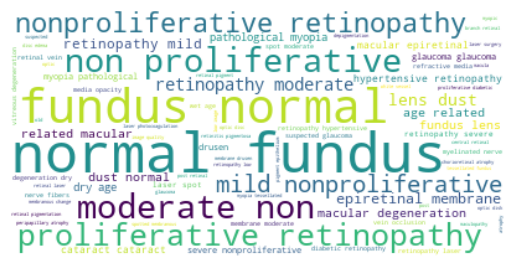

In [15]:
wordcloud = WordCloud(background_color="white").generate(left_text)

# Display the generated image:
# the matplotlib way:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

This visual indicates that the there is an error in the string being visualised. Further exploration is necessary.

In [16]:
# Take the original left_text and split on commas generating a list of all the values.
list_left_diagnosis = left_text.split(',') 

# Searching through the list for unique items and creating a set of it
set_left_diagnosis = set(list_left_diagnosis) 
len(set_left_diagnosis)

229

In [17]:
len(set_left_diagnosis)

229

In [18]:
# Displaying the set of the Left Diagnosis
set_left_diagnosis

{'',
 ' anterior segment image',
 ' asteroid hyalosis',
 ' atrophy',
 ' branch retinal artery occlusion',
 ' branch retinal vein occlusion',
 ' branch retinal vein occlusion，lens dust',
 ' cataract',
 ' cataract，lens dust',
 ' cataract，mild nonproliferative retinopathy',
 ' cataract，moderate non proliferative retinopathy',
 ' cataract，myelinated nerve fibers，moderate non proliferative retinopathy',
 ' cataract，suspected glaucoma',
 ' central retinal vein occlusion',
 ' central retinal vein occlusion，optic disc edema',
 ' chorioretinal atrophy',
 ' chorioretinal atrophy with pigmentation proliferation',
 ' chorioretinal atrophy with pigmentation proliferation，epiretinal membrane',
 ' chorioretinal atrophy with pigmentation proliferation，lens dust',
 ' chorioretinal atrophy，chorioretinal atrophy',
 ' depigmentation of the retinal pigment epithelium',
 ' diabetic retinopathy',
 ' diabetic retinopathy，dry age-related macular degeneration',
 ' diabetic retinopathy，post laser photocoagulatio

From the set above, it can be seen that there are terms in the list that are still aplit with the character '，'. This tells us that the content in the column need to have that character replaced with a comma. 
Additionally we also saw that there were items in the diagnosis columns that had a space before the item. so we need to account for this as well.

In [19]:
# Splitting on the character we discovered earlier
left_text = "".join(i + ',' for review in original_dataframe.LD for i in review.split('，')) 
right_text = "".join(i + ',' for review in original_dataframe.RD for i in review.split('，'))

# Combining the left and right into one full diagnostics
full_text = left_text + right_text

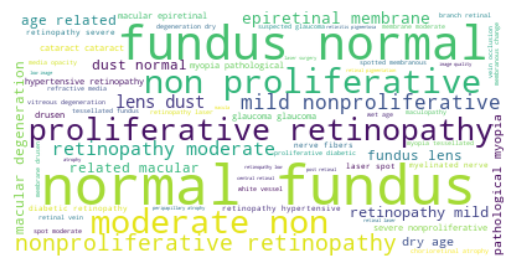

In [20]:
#display word cloud again #use frequency of words instead of the text
wordcloud = WordCloud(background_color="white").generate(left_text)

# Display the generated image:
# the matplotlib way:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [21]:
# Defines a function named 'remove_special_comma' that takes one argument 'diagnosis'.
def remove_special_comma(diagnosis):
    """
        Takes a diagnosis from a list and replace the special comma with a normal comma
        Args:
            diagnosis (String): a text in a list
        returns:
            text without special comma
    """
    diagnosis = diagnosis.replace('，', ',')
    return diagnosis

In [22]:
# Using the function to remove the special characters in the LD and RD columns
original_dataframe['LD'] = original_dataframe['LD'].map(remove_special_comma) 
original_dataframe['RD'] = original_dataframe['RD'].map(remove_special_comma)

original_dataframe.head(10)

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,"laser spot,moderate non proliferative retinopathy",moderate non proliferative retinopathy,0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,3_right.jpg,normal fundus,branch retinal artery occlusion,0,0,0,0,0,0,0,1
4,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1
5,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0
6,6,60,Male,6_left.jpg,6_right.jpg,macular epiretinal membrane,"moderate non proliferative retinopathy,epireti...",0,1,0,0,0,0,0,1
7,7,60,Female,7_left.jpg,7_right.jpg,drusen,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1
8,8,59,Male,8_left.jpg,8_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
9,9,54,Male,9_left.jpg,9_right.jpg,normal fundus,vitreous degeneration,0,0,0,0,0,0,0,1


There has to be a way to figure out what terms lead to what diagnosis.
Presently the data has two images per row (person) and we can either make it a row per eye and adjust the labels accordingly or cocantenate two eyes when passing the image to the model.

The Labels are as follow:
- Normal (N),
- Diabetes (D),
- Glaucoma (G),
- Cataract (C),
- Age related Macular Degeneration (A),
- Hypertension (H),
- Pathological Myopia (M),
- Other diseases/abnormalities (O)

We can select the columns that have a positive presence (1) for each of these columns and note the terms that most correlate with them.

In [23]:
# Filtering rows from 'original_dataframe' where the different diagnosis label has the value 1.
# This represents a subset of the data where the condition diagnosis is present.
normal_fundus = original_dataframe[original_dataframe['N'] == 1]
diabetes = original_dataframe[original_dataframe['D'] == 1]
glaucoma = original_dataframe[original_dataframe['G'] == 1]
cataract = original_dataframe[original_dataframe['C'] == 1]
armd = original_dataframe[original_dataframe['A'] == 1]
hypertension = original_dataframe[original_dataframe['H'] == 1]
myopia = original_dataframe[original_dataframe['M'] == 1]
others = original_dataframe[original_dataframe['O'] == 1]

For each of the tables above, we want to find out the diagnosis terms that most generate those results. We can accomplish this by taking a set of unique elements from the LD and RD columns. We'll then eliminate any overlap with any of the other sets for other labels.

In [24]:
def text_to_set(text):
    """
        Takes a text and returns a set of unique words in the text.
        Args:
            text (String): a text splittable with commas
        returns:
            set
    """
    text_list = text.split(',')
    return set(text_list)

In [25]:
def extract_text_from_diagnosis_columns(dataframe):
    """
        Takes a dataframe of data and return a text holding all the diagnosis 
        on the Left and right 
        Args:
            dataFrame: a dataframe
        returns:
            a list of text 
    """
    text_left = "".join(i + ',' for review in dataframe.LD for i in review.split(',')) 
    text_right = "".join(i + ',' for review in dataframe.RD for i in review.split(',')) 
    text = text_left + text_right
    return text

In [26]:
# Extracting the text from the diagnosis column using the extract_text_from_diagnosis_columns function
original_diagnosis = extract_text_from_diagnosis_columns(original_dataframe)

In [27]:
# Extracting unique diagnosis from the list of all the diagnosis using text_to_set function
original_diagnosis_set = text_to_set(original_diagnosis)
len(original_diagnosis_set)

103

In [28]:
# Displaying the unique set of diagnosis 
original_diagnosis_set

{'',
 'abnormal pigment ',
 'age-related macular degeneration',
 'anterior segment image',
 'arteriosclerosis',
 'asteroid hyalosis',
 'atrophic change',
 'atrophy',
 'branch retinal artery occlusion',
 'branch retinal vein occlusion',
 'cataract',
 'central retinal artery occlusion',
 'central retinal vein occlusion',
 'central serous chorioretinopathy',
 'chorioretinal atrophy',
 'chorioretinal atrophy with pigmentation proliferation',
 'choroidal nevus',
 'congenital choroidal coloboma',
 'depigmentation of the retinal pigment epithelium',
 'diabetic retinopathy',
 'diffuse chorioretinal atrophy',
 'diffuse retinal atrophy',
 'drusen',
 'dry age-related macular degeneration',
 'epiretinal membrane',
 'epiretinal membrane over the macula',
 'fundus laser photocoagulation spots',
 'glaucoma',
 'glial remnants anterior to the optic disc',
 'hypertensive retinopathy',
 'idiopathic choroidal neovascularization',
 'image offset',
 'intraretinal hemorrhage',
 'intraretinal microvascular ab

Having found out the set of all diagnostical terms across the LD and RD columns, the next step is to isolate the terms that uniquely identify a particular label.

In [29]:
pd.set_option('display.max_rows', None) #change the number of max rows available for display

In [30]:
others_left = "".join(i + ',' for review in others.LD for i in review.split(',')) 
others_right = "".join(i + ',' for review in others.RD for i in review.split(',')) 
others_text = others_left + others_right

In [31]:
# Filtering rows in subset normal_fundus of the data
# where only Normal fundus was 1 and the others are 0 
pure_normal_fundus = normal_fundus[(normal_fundus['C'] == 0) & (normal_fundus['N'] == 1) & (normal_fundus['A'] == 0) & (normal_fundus['G'] == 0)
                          & (normal_fundus['H'] == 0) & (normal_fundus['M'] == 0) & (normal_fundus['D'] == 0) & (normal_fundus['O'] == 0)]

# Extracting the text from the Left and Right Diagnosis Columns into one column
pure_normal_fundus_text = extract_text_from_diagnosis_columns(pure_normal_fundus)

# Extracting a set of unique values from the joint column
pure_normal_fundus_set = text_to_set(pure_normal_fundus_text)

In [32]:
# Filtering rows in subset cataract of the data 
# where only cataract was 1 and the others are 0 
pure_cataract = cataract[(cataract['C'] == 1) & (cataract['N'] == 0) & (cataract['A'] == 0) & (cataract['G'] == 0)
                          & (cataract['H'] == 0) & (cataract['M'] == 0) & (cataract['D'] == 0) & (cataract['O'] == 0)]

# Extracting the text from the Left and Right Diagnosis Columns into one column
pure_cataract_text = extract_text_from_diagnosis_columns(pure_cataract)

# Extracting a set of unique values from the joint column
pure_cataract_set = text_to_set(pure_cataract_text)

# Removing any part of the set that is in the normal fundus Set
pure_cataract_set -= pure_normal_fundus_set

In [33]:
# Filtering rows in subset diabetes of the data
# where only diabetes was 1 and the others are 0 
pure_diabetes = diabetes[(diabetes['C'] == 0) & (diabetes['N'] == 0) & (diabetes['A'] == 0) & (diabetes['G'] == 0)
                          & (diabetes['H'] == 0) & (diabetes['M'] == 0) & (diabetes['D'] == 1) & (diabetes['O'] == 0)]

# Extracting the text from the Left and Right Diagnosis Columns into one column
pure_diabetes_text = extract_text_from_diagnosis_columns(pure_diabetes)

# Extracting a set of unique values from the joint column
pure_diabetes_set = text_to_set(pure_diabetes_text)

# Removing any part of the set that is in the normal fundus Set
pure_diabetes_set -= pure_normal_fundus_set

In [34]:
# Filtering rows in subset armd of the data
# where only armd was 1 and the others are 0 
pure_armd = armd[(armd['C'] == 0) & (armd['N'] == 0) & (armd['A'] == 1) & (armd['G'] == 0)
                          & (armd['H'] == 0) & (armd['M'] == 0) & (armd['D'] == 0) & (armd['O'] == 0)]

# Extracting the text from the Left and Right Diagnosis Columns into one column
pure_armd_text = extract_text_from_diagnosis_columns(pure_armd)

# Extracting a set of unique values from the joint column
pure_armd_set = text_to_set(pure_armd_text)

# Removing any part of the set that is in the normal fundus Set
pure_armd_set -= pure_normal_fundus_set

In [35]:
# Filtering rows in subset hypertension of the data
# where only hypertension was 1 and the others are 0 
pure_hypertension = hypertension[(hypertension['C'] == 0) & (hypertension['N'] == 0) & (hypertension['A'] == 0) & (hypertension['G'] == 0)
                          & (hypertension['H'] == 1) & (hypertension['M'] == 0) & (hypertension['D'] == 0) & (hypertension['O'] == 0)]

# Extracting the text from the Left and Right Diagnosis Columns into one column
pure_hypertension_text = extract_text_from_diagnosis_columns(pure_hypertension)

# Extracting a set of unique values from the joint column
pure_hypertension_set = text_to_set(pure_hypertension_text)

# Removing any part of the set that is in the normal fundus Set
pure_hypertension_set -= pure_normal_fundus_set

In [36]:
# Filtering rows in subset glaucoma of the data
# where only glaucoma was 1 and the others are 0 
pure_glaucoma = glaucoma[(glaucoma['C'] == 0) & (glaucoma['N'] == 0) & (glaucoma['A'] == 0) & (glaucoma['G'] == 1)
                          & (glaucoma['H'] == 0) & (glaucoma['M'] == 0) & (glaucoma['D'] == 0) & (glaucoma['O'] == 0)]

# Extracting the text from the Left and Right Diagnosis Columns into one column
pure_glaucoma_text = extract_text_from_diagnosis_columns(pure_glaucoma)

# Extracting a set of unique values from the joint column
pure_glaucoma_set = text_to_set(pure_glaucoma_text)

# Removing any part of the set that is in the normal fundus Set
pure_glaucoma_set -= pure_normal_fundus_set

In [37]:
# Filtering rows in subset glaucoma of the data
# where only glaucoma was 1 and the others are 0 
pure_myopia = myopia[(myopia['C'] == 0) & (myopia['N'] == 0) & (myopia['A'] == 0) & (myopia['G'] == 0)
                          & (myopia['H'] == 0) & (myopia['M'] == 1) & (myopia['D'] == 0) & (myopia['O'] == 0)]

# Extracting the text from the Left and Right Diagnosis Columns into one column
pure_myopia_text = extract_text_from_diagnosis_columns(pure_myopia)

# Extracting a set of unique values from the joint column
pure_myopia_set = text_to_set(pure_myopia_text)

# Removing any part of the set that is in the normal fundus Set
pure_myopia_set -= pure_normal_fundus_set

In [38]:
# Filtering rows in subset glaucoma of the data
# where only glaucoma was 1 and the others are 0 
pure_others = others[(others['C'] == 0) & (others['N'] == 0) & (others['A'] == 0) & (others['G'] == 0)
                          & (others['H'] == 0) & (others['M'] == 0) & (others['D'] == 0) & (others['O'] == 1)]

# Extracting the text from the Left and Right Diagnosis Columns into one column
pure_others_text = extract_text_from_diagnosis_columns(pure_others)

# Extracting a set of unique values from the joint column
pure_others_set = text_to_set(pure_others_text)

# Removing any part of the set that is in the normal fundus Set
pure_others_set -= pure_normal_fundus_set

In [39]:
(pure_others_set & pure_diabetes_set & pure_cataract_set & pure_hypertension_set & pure_glaucoma_set & pure_myopia_set & pure_armd_set & pure_normal_fundus_set)

set()

There's no common element that leads to a pure diagnosis of a particular category. Hence we can hold that the presence of other terms will lead to a compound diagnosis.

In [40]:
# Getting the total of the pure set
total_pure_set = (pure_normal_fundus_set | pure_myopia_set | pure_glaucoma_set | pure_armd_set | pure_diabetes_set |
                         pure_hypertension_set | pure_cataract_set | pure_others_set)

# Displaying the set
total_pure_set

{'',
 'abnormal pigment ',
 'anterior segment image',
 'arteriosclerosis',
 'asteroid hyalosis',
 'atrophic change',
 'atrophy',
 'branch retinal artery occlusion',
 'branch retinal vein occlusion',
 'cataract',
 'central retinal artery occlusion',
 'central retinal vein occlusion',
 'chorioretinal atrophy',
 'chorioretinal atrophy with pigmentation proliferation',
 'congenital choroidal coloboma',
 'depigmentation of the retinal pigment epithelium',
 'diabetic retinopathy',
 'drusen',
 'dry age-related macular degeneration',
 'epiretinal membrane',
 'epiretinal membrane over the macula',
 'glaucoma',
 'hypertensive retinopathy',
 'idiopathic choroidal neovascularization',
 'laser spot',
 'lens dust',
 'low image quality',
 'macular coloboma',
 'macular epiretinal membrane',
 'macular hole',
 'maculopathy',
 'mild nonproliferative retinopathy',
 'moderate non proliferative retinopathy',
 'morning glory syndrome',
 'myelinated nerve fibers',
 'myopic maculopathy',
 'myopic retinopathy',

In [41]:
len(total_pure_set)

75

In [42]:
# Checking for items not in any of the pure sets but in the total set of diagnosis terms
remaining_set = (original_diagnosis_set - (pure_normal_fundus_set | pure_myopia_set | pure_glaucoma_set | pure_armd_set | pure_diabetes_set |
                         pure_hypertension_set | pure_cataract_set | pure_others_set)) 

remaining_set

{'age-related macular degeneration',
 'central serous chorioretinopathy',
 'choroidal nevus',
 'diffuse chorioretinal atrophy',
 'diffuse retinal atrophy',
 'fundus laser photocoagulation spots',
 'glial remnants anterior to the optic disc',
 'image offset',
 'intraretinal hemorrhage',
 'intraretinal microvascular abnormality',
 'macular pigmentation disorder',
 'myopia retinopathy',
 'old central retinal vein occlusion',
 'old choroiditis',
 'optic disk epiretinal membrane',
 'peripapillary atrophy',
 'punctate inner choroidopathy',
 'retinal detachment',
 'retinal pigment epithelial hypertrophy',
 'retinal pigment epithelium atrophy',
 'suspected cataract',
 'suspected diabetic retinopathy',
 'suspected macular epimacular membrane',
 'suspected microvascular anomalies',
 'suspected moderate non proliferative retinopathy',
 'suspicious diabetic retinopathy',
 'vascular loops',
 'vitreous opacity'}

In [43]:
# Checking the length of the original_diagnosis_set minus the total_pure set
print(len(original_diagnosis_set) - len(total_pure_set))

# Checking the length of the remaining_set
print(len(remaining_set))

# It is discovered they are the same

28
28


Visually, some items can be placed in specific categories such as age-related macular degeneration, myopia retinopathy. These will be confirmed.

In [44]:
original_dataframe[original_dataframe['RD'].str.contains('myopia retinopathy') | original_dataframe['LD'].str.contains('myopia retinopathy') ].head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
374,375,64,Male,375_left.jpg,375_right.jpg,"punctate inner choroidopathy,myopia retinopathy","punctate inner choroidopathy,myopia retinopathy",0,0,0,0,0,0,1,1
650,651,58,Male,651_left.jpg,651_right.jpg,"wet age-related macular degeneration,myopia re...",myopia retinopathy,0,0,0,0,1,0,1,0
935,938,76,Male,938_left.jpg,938_right.jpg,"dry age-related macular degeneration,myopia re...","diabetic retinopathy,dry age-related macular d...",0,1,0,0,1,0,1,0
1007,1020,67,Male,1020_left.jpg,1020_right.jpg,"glaucoma,intraretinal hemorrhage",myopia retinopathy,0,0,1,0,0,0,1,1
1038,1065,75,Male,1065_left.jpg,1065_right.jpg,dry age-related macular degeneration,myopia retinopathy,0,0,0,0,1,0,1,0


In [45]:
original_dataframe[original_dataframe['RD'].str.contains('age-related macular degeneration') | original_dataframe['LD'].str.contains('age-related macular degeneration') ].head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
43,43,35,Male,43_left.jpg,43_right.jpg,wet age-related macular degeneration,"dry age-related macular degeneration,glaucoma",0,0,1,0,1,0,0,0
48,48,69,Female,48_left.jpg,48_right.jpg,dry age-related macular degeneration,dry age-related macular degeneration,0,0,0,0,1,0,0,0
53,53,65,Female,53_left.jpg,53_right.jpg,wet age-related macular degeneration,dry age-related macular degeneration,0,0,0,0,1,0,0,0
55,55,62,Male,55_left.jpg,55_right.jpg,dry age-related macular degeneration,dry age-related macular degeneration,0,0,0,0,1,0,0,0
71,71,56,Female,71_left.jpg,71_right.jpg,diabetic retinopathy,"wet age-related macular degeneration,diabetic ...",0,1,0,0,1,0,0,0


Results:
- age-related macular degeneration : ARMD (A)
- myopia retinopathy : Myopia (M)

From the above tables we can see that myopia & age related.... should be in the pure myopia_set and pure_armd_set accordingly. Now the 'suspicious' diagnosis terms will be investigated.

In [46]:
original_dataframe[original_dataframe['RD'].str.contains('suspected cataract') | original_dataframe['LD'].str.contains('suspected cataract') ].head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
1555,2074,24,Male,2074_left.jpg,2074_right.jpg,"glaucoma,lens dust","cataract,suspected cataract",0,0,1,1,0,0,0,0


In [47]:
original_dataframe[original_dataframe['RD'].str.contains('suspected diabetic retinopathy') | original_dataframe['LD'].str.contains('suspected diabetic retinopathy') ].head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
752,754,64,Male,754_left.jpg,754_right.jpg,"hypertensive retinopathy,suspected diabetic re...","hypertensive retinopathy,suspected diabetic re...",0,1,0,0,0,1,0,0


In [48]:
original_dataframe[original_dataframe['RD'].str.contains('suspected microvascular anomalies') | original_dataframe['LD'].str.contains('suspected microvascular anomalies') ].head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
151,151,48,Male,151_left.jpg,151_right.jpg,normal fundus,"white vessel,proliferative diabetic retinopath...",0,1,0,0,0,0,0,1


In [49]:
original_dataframe[original_dataframe['RD'].str.contains('suspected macular epimacular membrane') | original_dataframe['LD'].str.contains('suspected macular epimacular membrane') ].head() 

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
1379,1559,56,Female,1559_left.jpg,1559_right.jpg,pathological myopia,"pathological myopia,suspected macular epimacul...",0,0,0,0,0,0,1,1


In [50]:
original_dataframe[original_dataframe['RD'].str.contains('suspected moderate non proliferative retinopathy') | original_dataframe['LD'].str.contains('suspected moderate non proliferative retinopathy') ].head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
1363,1543,30,Female,1543_left.jpg,1543_right.jpg,suspected moderate non proliferative retinopat...,pathological myopia,0,1,0,0,0,0,1,0


In [51]:
original_dataframe[original_dataframe['RD'].str.contains('suspicious diabetic retinopathy') | original_dataframe['LD'].str.contains('suspicious diabetic retinopathy') ] .head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
744,746,59,Male,746_left.jpg,746_right.jpg,"suspected glaucoma,suspicious diabetic retinop...","suspected glaucoma,suspicious diabetic retinop...",0,1,1,0,0,0,0,0


Reults: 
- 'suspected cataract': cataract
- 'suspected diabetic retinopathy': diabetes
- 'suspected macular epimacular membrane': others
- 'suspected microvascular anomalies': others
- 'suspected moderate non proliferative retinopathy': diabetes
- 'suspicious diabetic retinopathy': diabetes

##### The above items were added to specific categories. 
Other items will now be investigated. I hypothesize that most of them will be under Others.

In [52]:
original_dataframe[original_dataframe['RD'].str.contains('vitreous opacity')].head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
1246,1373,68,Male,1373_left.jpg,1373_right.jpg,hypertensive retinopathy,"hypertensive retinopathy,branch retinal vein o...",0,0,0,0,0,1,0,1


In [53]:
original_dataframe[original_dataframe['RD'].str.contains('central serous chorioretinopathy') | original_dataframe['LD'].str.contains('central serous chorioretinopathy') ].head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
1549,2053,47,Male,2053_left.jpg,2053_right.jpg,dry age-related macular degeneration,central serous chorioretinopathy,0,0,0,0,1,0,0,1


In [54]:
original_dataframe[original_dataframe['RD'].str.contains('choroidal nevus') | original_dataframe['LD'].str.contains('choroidal nevus') ] .head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
1135,1202,42,Female,1202_left.jpg,1202_right.jpg,"dry age-related macular degeneration,choroidal...",dry age-related macular degeneration,0,0,0,0,1,0,0,1


In [55]:
original_dataframe[original_dataframe['RD'].str.contains('diffuse chorioretinal atrophy') | original_dataframe['LD'].str.contains('diffuse chorioretinal atrophy') ] .head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
845,847,56,Female,847_left.jpg,847_right.jpg,"wet age-related macular degeneration,diffuse c...","dry age-related macular degeneration,post lase...",0,0,0,0,1,0,0,1


In [56]:
original_dataframe[original_dataframe['RD'].str.contains('diffuse retinal atrophy') | original_dataframe['LD'].str.contains('diffuse retinal atrophy') ] .head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
1179,1255,33,Male,1255_left.jpg,1255_right.jpg,"glaucoma,diffuse retinal atrophy",glaucoma,0,0,1,0,0,0,0,1


In [57]:
original_dataframe[original_dataframe['RD'].str.contains('fundus laser photocoagulation spots') | original_dataframe['LD'].str.contains('fundus laser photocoagulation spots')] .head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
1196,1273,62,Male,1273_left.jpg,1273_right.jpg,fundus laser photocoagulation spots,"glaucoma,fundus laser photocoagulation spots",0,0,1,0,0,0,0,1


In [58]:
original_dataframe[original_dataframe['RD'].str.contains('glial remnants anterior to the optic disc') | original_dataframe['LD'].str.contains('glial remnants anterior to the optic disc')].head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
755,757,58,Female,757_left.jpg,757_right.jpg,moderate non proliferative retinopathy,glial remnants anterior to the optic disc,0,1,0,0,0,0,0,1


In [59]:
original_dataframe[original_dataframe['RD'].str.contains('image offset') | original_dataframe['LD'].str.contains('image offset')].head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
1170,1243,81,Female,1243_left.jpg,1243_right.jpg,image offset,"dry age-related macular degeneration,glaucoma",0,0,1,0,1,0,0,0


In [60]:
original_dataframe[original_dataframe['RD'].str.contains('intraretinal hemorrhage') | original_dataframe['LD'].str.contains('intraretinal hemorrhage')].head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
1007,1020,67,Male,1020_left.jpg,1020_right.jpg,"glaucoma,intraretinal hemorrhage",myopia retinopathy,0,0,1,0,0,0,1,1
1199,1277,74,Male,1277_left.jpg,1277_right.jpg,"glaucoma,intraretinal hemorrhage",glaucoma,0,0,1,0,0,0,0,1


In [61]:
original_dataframe[original_dataframe['RD'].str.contains('intraretinal microvascular abnormality') | original_dataframe['LD'].str.contains('intraretinal microvascular abnormality')] .head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
3381,4551,53,Male,4551_left.jpg,4551_right.jpg,mild nonproliferative retinopathy,intraretinal microvascular abnormality,0,1,0,0,0,0,0,1
3480,4659,42,Male,4659_left.jpg,4659_right.jpg,mild nonproliferative retinopathy,intraretinal microvascular abnormality,0,1,0,0,0,0,0,1


Results:
- 'central serous chorioretinopathy' : Others
- 'choroidal nevus': Others
- 'diffuse chorioretinal atrophy': Others
- 'diffuse retinal atrophy': Others
- 'fundus laser photocoagulation spots': Others
- 'glial remnants anterior to the optic disc': Others
- *'image offset': Normal
- 'intraretinal hemorrhage': Others
- 'intraretinal microvascular abnormality': Others
- 'vitreous opacity' : Others

*This is determined by inference. The only situations in which normal is not highlighted is if there's a disease, so given O was not positive and the other two labels are spoken for, I would estimate normal to be the most likely

In [62]:
original_dataframe[original_dataframe['RD'].str.contains('macular pigmentation disorder') | original_dataframe['LD'].str.contains('macular pigmentation disorder')] 

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
1293,1442,63,Male,1442_left.jpg,1442_right.jpg,"glaucoma,mild nonproliferative retinopathy,mac...",pigmentation disorder,0,1,1,0,0,0,0,1


In [63]:
original_dataframe[original_dataframe['RD'].str.contains('old central retinal vein occlusion') | original_dataframe['LD'].str.contains('old central retinal vein occlusion')] 

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
1152,1221,70,Male,1221_left.jpg,1221_right.jpg,"glaucoma,macular epiretinal membrane","glaucoma,old central retinal vein occlusion",0,0,1,0,0,0,0,1
1186,1263,62,Male,1263_left.jpg,1263_right.jpg,old central retinal vein occlusion,"glaucoma,hypertensive retinopathy",0,0,1,0,0,1,0,1
1547,2048,63,Male,2048_left.jpg,2048_right.jpg,hypertensive retinopathy,"glaucoma,old central retinal vein occlusion",0,0,1,0,0,1,0,1


In [64]:
original_dataframe[original_dataframe['RD'].str.contains('old choroiditis') | original_dataframe['LD'].str.contains('old choroiditis')] 

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
377,378,54,Male,378_left.jpg,378_right.jpg,"old choroiditis,macular epiretinal membrane",moderate non proliferative retinopathy,0,1,0,0,0,0,0,1


In [65]:
original_dataframe[original_dataframe['RD'].str.contains('optic disk epiretinal membrane') | original_dataframe['LD'].str.contains('optic disk epiretinal membrane')] 

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
450,451,56,Male,451_left.jpg,451_right.jpg,optic disk epiretinal membrane,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1


In [66]:
original_dataframe[original_dataframe['RD'].str.contains('peripapillary atrophy') | original_dataframe['LD'].str.contains('peripapillary atrophy')].head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
1387,1567,47,Male,1567_left.jpg,1567_right.jpg,"tessellated fundus,peripapillary atrophy",pathological myopia,0,0,0,0,0,0,1,1
1391,1571,65,Male,1571_left.jpg,1571_right.jpg,pathological myopia,"tessellated fundus,peripapillary atrophy",0,0,0,0,0,0,1,1
1393,1573,69,Female,1573_left.jpg,1573_right.jpg,"tessellated fundus,peripapillary atrophy",pathological myopia,0,0,0,0,0,0,1,1
1394,1574,73,Female,1574_left.jpg,1574_right.jpg,"tessellated fundus,peripapillary atrophy",pathological myopia,0,0,0,0,0,0,1,1
1407,1591,62,Female,1591_left.jpg,1591_right.jpg,pathological myopia,"tessellated fundus,peripapillary atrophy",0,0,0,0,0,0,1,1


In [67]:
original_dataframe[original_dataframe['RD'].str.contains('punctate inner choroidopathy') | original_dataframe['LD'].str.contains('punctate inner choroidopathy')] 

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
374,375,64,Male,375_left.jpg,375_right.jpg,"punctate inner choroidopathy,myopia retinopathy","punctate inner choroidopathy,myopia retinopathy",0,0,0,0,0,0,1,1


In [68]:
original_dataframe[original_dataframe['RD'].str.contains('retinal detachment') | original_dataframe['LD'].str.contains('retinal detachment')] 

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
20,20,64,Female,20_left.jpg,20_right.jpg,rhegmatogenous retinal detachment,"lens dust,normal fundus",0,0,0,0,0,0,0,1
408,409,55,Male,409_left.jpg,409_right.jpg,"lens dust,rhegmatogenous retinal detachment","lens dust,normal fundus",0,0,0,0,0,0,0,1
1440,1638,59,Male,1638_left.jpg,1638_right.jpg,pathological myopia,"retinal detachment,tessellated fundus",0,0,0,0,0,0,1,1


In [69]:
original_dataframe[original_dataframe['RD'].str.contains('retinal pigment epithelial hypertrophy') | original_dataframe['LD'].str.contains('retinal pigment epithelial hypertrophy')] 

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
599,600,50,Male,600_left.jpg,600_right.jpg,mild nonproliferative retinopathy,"retinal pigment epithelial hypertrophy,moderat...",0,1,0,0,0,0,0,1
699,701,60,Male,701_left.jpg,701_right.jpg,normal fundus,"moderate non proliferative retinopathy,retinal...",0,1,0,0,0,0,0,1


In [70]:
original_dataframe[original_dataframe['RD'].str.contains('retinal pigment epithelium atrophy') | original_dataframe['LD'].str.contains('retinal pigment epithelium atrophy')] 

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
108,108,54,Female,108_left.jpg,108_right.jpg,"retinal pigment epithelium atrophy,diabetic re...",normal fundus,0,1,0,0,0,0,0,1


In [71]:
original_dataframe[original_dataframe['RD'].str.contains('vascular loops') | original_dataframe['LD'].str.contains('vascular loops')] 

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
791,793,66,Female,793_left.jpg,793_right.jpg,"lens dust,moderate non proliferative retinopathy","lens dust,vascular loops",0,1,0,0,0,0,0,1


Results: 
- 'macular pigmentation disorder': Others
- 'old central retinal vein occlusion': Others
- 'old choroiditis': Others
- 'optic disk epiretinal membrane': Others
- 'peripapillary atrophy': Others
- 'punctate inner choroidopathy': Others
- 'retinal detachment': Others
- 'retinal pigment epithelial hypertrophy': Others
- 'retinal pigment epithelium atrophy': Others
- 'vascular loops': Others

Most of the items from the remaining_set are for the Others category so the label sets will be adjusted accordingly

In [72]:
# Creating a list of the remaining item in the remaining_set that cant be categorized
remaining_others_list = ['suspected macular epimacular membrane','suspected microvascular anomalies','central serous chorioretinopathy' 
,'diffuse chorioretinal atrophy','choroidal nevus','diffuse retinal atrophy','fundus laser photocoagulation spots' 
,'glial remnants anterior to the optic disc', 'intraretinal hemorrhage', 'intraretinal microvascular abnormality'
,'macular pigmentation disorder','old central retinal vein occlusion','old choroiditis','optic disk epiretinal membrane'
,'peripapillary atrophy','punctate inner choroidopathy','retinal detachment','retinal pigment epithelial hypertrophy'
,'retinal pigment epithelium atrophy','vascular loops','vitreous opacity']

len(remaining_others_list)

21

In [73]:
# Adding the items in the remaining_set that could be categorized
# Adding to their respective category
pure_armd_set.add('age-related macular degeneration')
pure_myopia_set.add('myopia retinopathy')
pure_diabetes_set.update(['suspected diabetic retinopathy', 'suspected moderate non proliferative retinopathy', 'suspicious diabetic retinopathy'])
pure_cataract_set.add('suspected cataract')
pure_others_set.update(remaining_others_list)
pure_normal_fundus_set.add('image offset')



In [74]:
# Adding all the pure set of diagnosis into one total pure set
total_pure_set = (pure_normal_fundus_set | pure_myopia_set | pure_glaucoma_set | pure_armd_set | pure_diabetes_set |
                         pure_hypertension_set | pure_cataract_set | pure_others_set)
len(total_pure_set)

103

In [75]:
original_diagnosis_set - total_pure_set

set()

## Fixing Data so it's a single image to a row.
The idea will be to isolate the relevant left image columns and relevant right image columns + data.

In [76]:
pd.set_option('display.max_rows', 10)
original_dataframe

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,LD,RD,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,"laser spot,moderate non proliferative retinopathy",moderate non proliferative retinopathy,0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,3_right.jpg,normal fundus,branch retinal artery occlusion,0,0,0,0,0,0,0,1
4,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,4686,63,Male,4686_left.jpg,4686_right.jpg,severe nonproliferative retinopathy,proliferative diabetic retinopathy,0,1,0,0,0,0,0,0
3496,4688,42,Male,4688_left.jpg,4688_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0
3497,4689,54,Male,4689_left.jpg,4689_right.jpg,mild nonproliferative retinopathy,normal fundus,0,1,0,0,0,0,0,0
3498,4690,57,Male,4690_left.jpg,4690_right.jpg,mild nonproliferative retinopathy,mild nonproliferative retinopathy,0,1,0,0,0,0,0,0


> Left Columns are: [ID, Patient Age, Patient Sex, Left-Fundus, LD, N, D, G, C, A, H, M, O]

> Right Columns are: [ID, Patient Age, Patient Sex, Right-Fundus, RD, N, D, G, C, A, H, M, O]

> Renaming the following: 
> - ID column to Patient ID
> - LD/RD to Diagnosis
> - Left Fundus/Right Fundus to Filename

In [77]:
# Getting the current column name of the dataframe
original_dataframe.columns

Index(['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'LD',
       'RD', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O'],
      dtype='object')

In [78]:
# Creating the left and right Images with their column
left_fundus_images = original_dataframe.filter(['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'LD', 'N', 'D', 'G', 'C', 'A','H', 'M', 'O'])
right_fundus_images = original_dataframe.filter(['ID', 'Patient Age', 'Patient Sex', 'Right-Fundus', 'RD', 'N', 'D', 'G', 'C', 'A','H', 'M', 'O'])

In [79]:
# Renaming the columns 
left_fundus_images.rename(columns = {'LD':'Diagnosis', 'ID': 'Patient ID', 'Left-Fundus': 'Filename'}, inplace = True)
right_fundus_images.rename(columns = {'RD':'Diagnosis', 'ID': 'Patient ID', 'Right-Fundus': 'Filename'}, inplace = True)

In [80]:
# Changing all the values of the diagnosis to 0
left_fundus_images.loc[:, ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']] = 0
right_fundus_images.loc[:, ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']] = 0

In [81]:
# Create an List of the diagnosis
left_fundus_images['Diagnosis'] = left_fundus_images['Diagnosis'].apply(lambda x: x.split(','))
right_fundus_images['Diagnosis'] = right_fundus_images['Diagnosis'].apply(lambda x: x.split(','))

In [82]:
# Define a function named 'filter_values_in_set' that takes three parameters:
# 'dataframe' which is the DataFrame to operate on,
# 'unique_set' which is a set containing unique values to filter by,
# 'column' which is the column in the DataFrame where the filter result will be marked.
def filter_values_in_set(dataframe, unique_set, column):
    filter_condition = dataframe['Diagnosis'].apply(lambda x: any(item in unique_set for item in x))
    dataframe.loc[filter_condition, column] = 1

In [83]:
# Using the function on each set of diagnosis on the left diagnosis
filter_values_in_set(left_fundus_images, pure_normal_fundus_set, 'N')
filter_values_in_set(left_fundus_images, pure_diabetes_set, 'D')
filter_values_in_set(left_fundus_images, pure_glaucoma_set, 'G')
filter_values_in_set(left_fundus_images, pure_cataract_set, 'C')
filter_values_in_set(left_fundus_images, pure_armd_set, 'A')
filter_values_in_set(left_fundus_images, pure_hypertension_set, 'H')
filter_values_in_set(left_fundus_images, pure_myopia_set, 'M')
filter_values_in_set(left_fundus_images, pure_others_set, 'O')

In [84]:
# Using the function on each set of diagnosis on the right diagnosis 
filter_values_in_set(right_fundus_images, pure_normal_fundus_set, 'N')
filter_values_in_set(right_fundus_images, pure_diabetes_set, 'D')
filter_values_in_set(right_fundus_images, pure_glaucoma_set, 'G')
filter_values_in_set(right_fundus_images, pure_cataract_set, 'C')
filter_values_in_set(right_fundus_images, pure_armd_set, 'A')
filter_values_in_set(right_fundus_images, pure_hypertension_set, 'H')
filter_values_in_set(right_fundus_images, pure_myopia_set, 'M')
filter_values_in_set(right_fundus_images, pure_others_set, 'O')

In [85]:
right_fundus_images

,Patient ID,Patient Age,Patient Sex,Filename,Diagnosis,N,D,G,C,A,H,M,O
0,0,69,Female,0_right.jpg,[normal fundus],1,0,0,0,0,0,0,0
1,1,57,Male,1_right.jpg,[normal fundus],1,0,0,0,0,0,0,0
2,2,42,Male,2_right.jpg,[moderate non proliferative retinopathy],0,1,0,0,0,0,0,0
3,3,66,Male,3_right.jpg,[branch retinal artery occlusion],0,0,0,0,0,0,0,1
4,4,53,Male,4_right.jpg,[mild nonproliferative retinopathy],0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,4686,63,Male,4686_right.jpg,[proliferative diabetic retinopathy],0,1,0,0,0,0,0,0
3496,4688,42,Male,4688_right.jpg,[moderate non proliferative retinopathy],0,1,0,0,0,0,0,0
3497,4689,54,Male,4689_right.jpg,[normal fundus],1,0,0,0,0,0,0,0
3498,4690,57,Male,4690_right.jpg,[mild nonproliferative retinopathy],0,1,0,0,0,0,0,0


In [86]:
left_fundus_images

,Patient ID,Patient Age,Patient Sex,Filename,Diagnosis,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,[cataract],0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,[normal fundus],1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,"[laser spot, moderate non proliferative retino...",0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,[normal fundus],1,0,0,0,0,0,0,0
4,4,53,Male,4_left.jpg,[macular epiretinal membrane],0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,4686,63,Male,4686_left.jpg,[severe nonproliferative retinopathy],0,1,0,0,0,0,0,0
3496,4688,42,Male,4688_left.jpg,[moderate non proliferative retinopathy],0,1,0,0,0,0,0,0
3497,4689,54,Male,4689_left.jpg,[mild nonproliferative retinopathy],0,1,0,0,0,0,0,0
3498,4690,57,Male,4690_left.jpg,[mild nonproliferative retinopathy],0,1,0,0,0,0,0,0


In [87]:
# A new dataframe holding the left and right diagnosis in one column
new_dataframe = pd.concat([left_fundus_images, right_fundus_images], ignore_index = True)

In [88]:
new_dataframe

,Patient ID,Patient Age,Patient Sex,Filename,Diagnosis,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,[cataract],0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,[normal fundus],1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,"[laser spot, moderate non proliferative retino...",0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,[normal fundus],1,0,0,0,0,0,0,0
4,4,53,Male,4_left.jpg,[macular epiretinal membrane],0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,4686,63,Male,4686_right.jpg,[proliferative diabetic retinopathy],0,1,0,0,0,0,0,0
6996,4688,42,Male,4688_right.jpg,[moderate non proliferative retinopathy],0,1,0,0,0,0,0,0
6997,4689,54,Male,4689_right.jpg,[normal fundus],1,0,0,0,0,0,0,0
6998,4690,57,Male,4690_right.jpg,[mild nonproliferative retinopathy],0,1,0,0,0,0,0,0


In [89]:
new_dataframe['Diagnosis'] = new_dataframe['Diagnosis'].apply(lambda x: ','.join(x))
new_dataframe

,Patient ID,Patient Age,Patient Sex,Filename,Diagnosis,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,cataract,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,"laser spot,moderate non proliferative retinopathy",0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,normal fundus,1,0,0,0,0,0,0,0
4,4,53,Male,4_left.jpg,macular epiretinal membrane,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,4686,63,Male,4686_right.jpg,proliferative diabetic retinopathy,0,1,0,0,0,0,0,0
6996,4688,42,Male,4688_right.jpg,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0
6997,4689,54,Male,4689_right.jpg,normal fundus,1,0,0,0,0,0,0,0
6998,4690,57,Male,4690_right.jpg,mild nonproliferative retinopathy,0,1,0,0,0,0,0,0


In [90]:
# Converting the dataframe to an excel format
new_dataframe.to_excel('Processed_data.xlsx', index=False)

In [91]:
# Reading the new processed_data
df = pd.read_excel('Processed_data.xlsx')
df.head()

,Patient ID,Patient Age,Patient Sex,Filename,Diagnosis,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,cataract,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,"laser spot,moderate non proliferative retinopathy",0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,normal fundus,1,0,0,0,0,0,0,0
4,4,53,Male,4_left.jpg,macular epiretinal membrane,0,0,0,0,0,0,0,1


### Correlation

### Choose columns 

In [92]:
# Choose columns 
choice_columns = original_dataframe.drop(['ID','N', 'D', 'G','C', 'A', 'H', 'M', 'O','Left-Fundus','Right-Fundus'], axis=1)

In [93]:
choice_columns

,Patient Age,Patient Sex,LD,RD
0,69,Female,cataract,normal fundus
1,57,Male,normal fundus,normal fundus
2,42,Male,"laser spot,moderate non proliferative retinopathy",moderate non proliferative retinopathy
3,66,Male,normal fundus,branch retinal artery occlusion
4,53,Male,macular epiretinal membrane,mild nonproliferative retinopathy
...,...,...,...,...
3495,63,Male,severe nonproliferative retinopathy,proliferative diabetic retinopathy
3496,42,Male,moderate non proliferative retinopathy,moderate non proliferative retinopathy
3497,54,Male,mild nonproliferative retinopathy,normal fundus
3498,57,Male,mild nonproliferative retinopathy,mild nonproliferative retinopathy


In [94]:
label_encoder = LabelEncoder()

# Apply Label Encoding to specific columns
choice_columns['Patient Sex'] = label_encoder.fit_transform(choice_columns['Patient Sex']) 
choice_columns['LD'] = label_encoder.fit_transform(choice_columns['LD'])
choice_columns['RD'] = label_encoder.fit_transform(choice_columns['RD'])

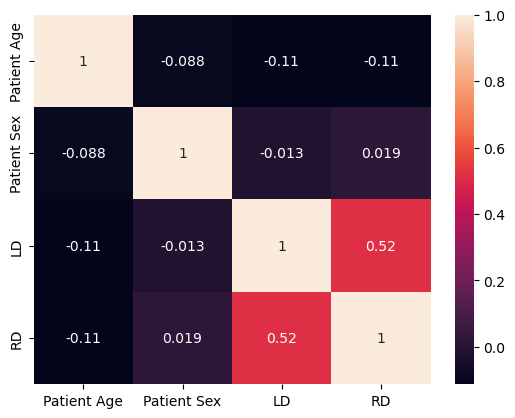

In [95]:
corr_matrix = choice_columns.corr()

# Visualize the correlation matrix as a heatmap
sns.heatmap(corr_matrix, annot=True)
plt.show()


### Some eye diseases compared to a normal eye

<table>
   <tr style="text-align: center;">
    <th>Cataract</th>
    <th>Normal</th>
  </tr>
  <tr>
    <td><img src="./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training Images/0_left.jpg" alt="Cataract" width="300" height="300"></td>
    <td><img src="./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training Images/1_left.jpg" alt="Normal" width="300" height="300"></td>
  </tr>
</table>

<table>
   <tr style="text-align: center;">
    <th>pathological myopia</th>
    <th>Normal</th>
  </tr>
  <tr>
    <td><img src="./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training Images/13_left.jpg" alt="pathological myopia" width="300" height="300"></td>
    <td><img src="./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training Images/1_left.jpg" alt="Normal" width="300" height="300"></td>
  </tr>
</table>


<table>
   <tr style="text-align: center;">
    <th>retinal pigmentation</th>
    <th>Normal</th>
  </tr>
  <tr>
    <td><img src="./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training Images/12_left.jpg" alt="retinal pigmentation" width="300" height="300"></td>
    <td><img src="./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training Images/1_left.jpg" alt="Normal" width="300" height="300"></td>
  </tr>
</table>

<table>
   <tr style="text-align: center;">
    <th>rhegmatogenous retinal detachment</th>
    <th>Normal</th>
  </tr>
  <tr>
    <td><img src="./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training Images/20_left.jpg" alt="retinal pigmentation" width="300" height="300"></td>
    <td><img src="./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training Images/1_left.jpg" alt="Normal" width="300" height="300"></td>
  </tr>
</table>

<table>
   <tr style="text-align: center;">
    <th>epiretinal membrane</th>
    <th>Normal</th>
  </tr>
  <tr>
    <td><img src="./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training Images/29_left.jpg" alt="epiretinal membrane" width="300" height="300"></td>
    <td><img src="./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training Images/1_left.jpg" alt="Normal" width="300" height="300"></td>
  </tr>
</table>



<table>
   <tr style="text-align: center;">
    <th>macular hole</th>
    <th>Normal</th>
  </tr>
  <tr>
    <td><img src="./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training Images/38_left.jpg" alt="macular hole" width="300" height="300"></td>
    <td><img src="./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training Images/1_left.jpg" alt="Normal" width="300" height="300"></td>
  </tr>
</table>

<table>
   <tr style="text-align: center;">
    <th>chorioretinal atrophy</th>
    <th>Normal</th>
  </tr>
  <tr>
    <td><img src="./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training Images/78_left.jpg" alt="chorioretinal atrophy" width="300" height="300"></td>
    <td><img src="./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/Training Images/1_left.jpg" alt="Normal" width="300" height="300"></td>
  </tr>
</table>



# VISUALIZING THE DIAGNOSIS SET
Displaying the number of diagnosis for each diagnosis in the set of diagnosis in the training data.

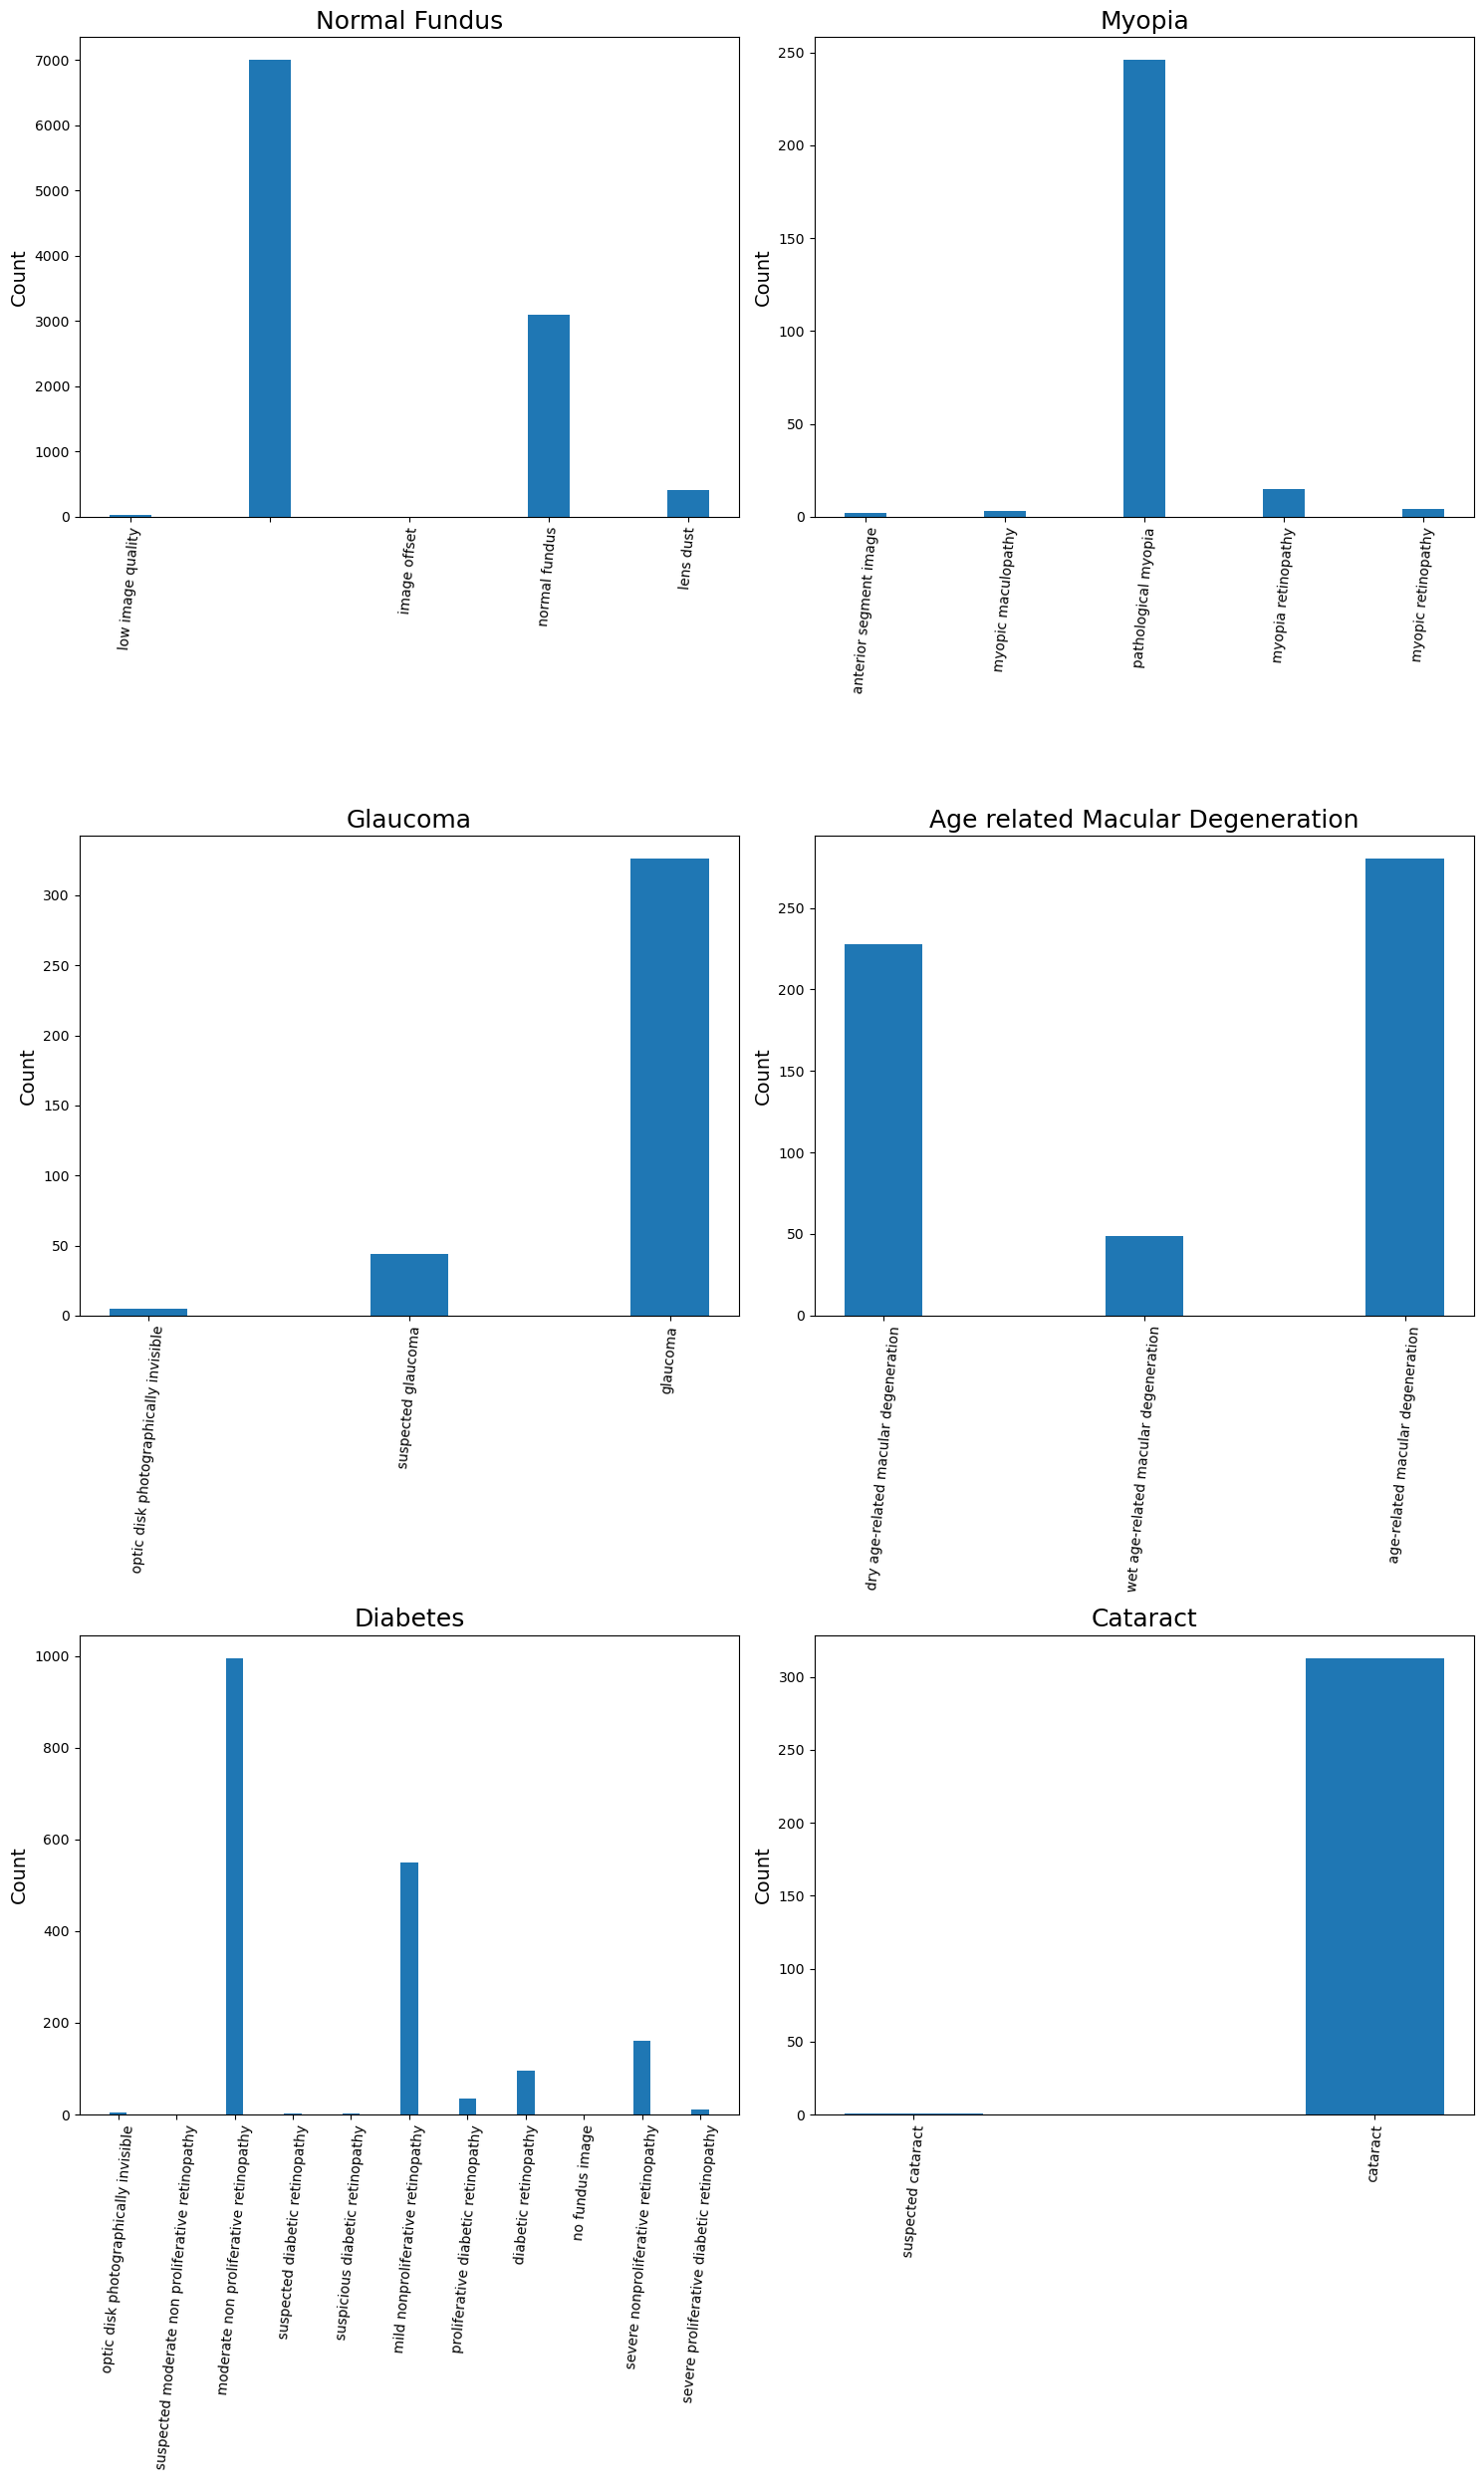

In [96]:
# Creating a list of the different set of diagnosis 
diagnosis_set = [pure_normal_fundus_set, pure_myopia_set, pure_glaucoma_set, 
                 pure_armd_set ,pure_diabetes_set, pure_cataract_set]

# Creating a list of the diagnosis name 
diagnosis_name = ["Normal Fundus", "Myopia", "Glaucoma", "Age related Macular Degeneration", "Diabetes", "Cataract"]

# Creating the plot size and number 
fig, axes = plt.subplots(3, 2, figsize=(15, 25), sharey=False)

for dia_set in diagnosis_set:
    diz_count = [df["Diagnosis"].str.contains(dis).sum() for dis in dia_set]
    x = list(dia_set)
    y = diz_count
    
    i = diagnosis_set.index(dia_set)
    row, col = divmod(i, 2)
    ax = axes[row, col]
    ax.bar(x, y, width = 0.3)
    ax.set_title(diagnosis_name[i], fontsize=18)
    ax.set_ylabel('Count', fontsize=14)
    ax.tick_params(axis='x', labelrotation = 85)

plt.tight_layout()